# **Import Everthing**

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             accuracy_score,
                             confusion_matrix)
print("Everthing is loaded Boss")

Everthing is loaded Boss


# **Data exploration**

## **Load The Data**

In [2]:
file_path = input("Enter the File Path Baby: ")
df = pd.read_csv(file_path)
print('Data Loaded Baby')

Data Loaded Baby


## **Exploration**

In [4]:
print(f'The dataset have {df.shape[0]} Rows and {df.shape[1]} columns with {df.duplicated().sum()} Duplicates')

The dataset have 6050 Rows and 9 columns with 50 Duplicates


In [5]:
df.sample(10)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,malignant
4342,25.69,13.40,160.27,1225.39,0.1008,0.1561,0.3988,0.1682,1
1359,20.22,36.14,87.57,348.04,0.0765,0.0955,0.3287,0.1821,1
519,9.61,13.83,136.65,949.25,0.1630,0.0206,0.0513,0.1546,0
5826,21.3,19.53,74.84,NaN,0.1132,0.1096,0.1891,0.2368,1
3049,12.34,25.02,119.31,195.17,0.1586,0.1333,0.4149,0.2993,0
5493,12.59,33.40,48.70,1157.01,0.0884,0.1796,0.3052,0.1186,0
1739,15.94,11.44,179.39,1031.20,0.1523,0.2726,0.4283,0.1008,0
2854,8.44,23.94,114.93,2308.07,0.0752,0.2856,0.2723,0.1470,0
4004,9.58,23.78,195.93,1626.91,0.0914,0.1313,0.0876,0.1699,0
836,27.96,20.37,187.02,234.80,0.1289,NaN,0.4142,0.2029,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6050 entries, 0 to 6049
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   radius_mean       5931 non-null   str    
 1   texture_mean      5930 non-null   float64
 2   perimeter_mean    5928 non-null   float64
 3   area_mean         5930 non-null   float64
 4   smoothness_mean   5929 non-null   float64
 5   compactness_mean  5930 non-null   float64
 6   concavity_mean    5930 non-null   float64
 7   symmetry_mean     5926 non-null   float64
 8   malignant         6050 non-null   int64  
dtypes: float64(7), int64(1), str(1)
memory usage: 453.7 KB


In [6]:
df.describe()

,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,malignant
count,5930.000000,5928.000000,5930.000000,5929.000000,5930.000000,5930.000000,5926.000000,6050.000000
mean,24.351444,120.268937,1365.767821,0.109372,0.185733,0.214909,0.199383,0.495207
std,8.922132,46.124549,1450.956596,0.042082,0.113912,0.124407,0.060103,0.500018
min,-3.000000,40.040000,140.110000,0.050000,0.020000,0.000100,-1.000000,0.000000
25%,16.702500,80.427500,771.702500,0.079800,0.101300,0.108100,0.148425,0.000000
50%,24.245000,120.700000,1356.080000,0.109100,0.185800,0.214150,0.199000,0.000000
75%,32.080000,160.475000,1935.747500,0.137700,0.266875,0.324600,0.250200,1.000000
max,39.990000,199.990000,99999.000000,2.000000,5.000000,0.430000,0.300000,1.000000


In [7]:
print(df.isna().sum())

radius_mean         119
texture_mean        120
perimeter_mean      122
area_mean           120
smoothness_mean     121
compactness_mean    120
concavity_mean      120
symmetry_mean       124
malignant             0
dtype: int64


# **Data Cleaning**

## **Create Copy**

In [8]:
df_copy = df.copy()
print("copy Create Boss")

copy Create Boss


## **DataType**

In [10]:
df_copy['radius_mean'] = df_copy['radius_mean'].replace('_err','',regex=True).astype('float')

## **Impossible Values**

In [12]:
Columns = ['radius_mean',
           'texture_mean',
           'symmetry_mean']

for col in Columns:
    df_copy.loc[df_copy[col]<0,col] = np.nan

## **Outliers**

In [14]:
Columns = ['perimeter_mean',
           'area_mean',
           'smoothness_mean',
           'compactness_mean']

for col in Columns:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_copy.loc[df_copy[col] < lower, col] = np.nan
    df_copy.loc[df_copy[col] > upper, col] = np.nan

print("Outliers Handled ✅")

Outliers Handled ✅


## **Duplicates**

In [16]:
print("Dateset have duplicates: ")
print(f"Before: {df_copy.duplicated().sum()}")
df_copy.drop_duplicates(inplace=True)
print(f"After: {df_copy.duplicated().sum()}")

Dateset have duplicates: 
Before: 50
After: 0


## **NaN Values**

In [18]:
print("NaN values in the Dataset is: ")
print(df_copy.isna().sum())

Round = df_copy.columns.tolist()
Round.remove('malignant')
for col in Round:
    df_copy[col] = df_copy[col].fillna(round(df_copy[col].median(),2))
    
print("NaN values in the Dataset After Cleaning is: ")
print(df_copy.isna().sum())

NaN values in the Dataset is: 
radius_mean         121
texture_mean        121
perimeter_mean      120
area_mean           121
smoothness_mean     121
compactness_mean    121
concavity_mean      120
symmetry_mean       121
malignant             0
dtype: int64
NaN values in the Dataset After Cleaning is: 
radius_mean         0
texture_mean        0
perimeter_mean      0
area_mean           0
smoothness_mean     0
compactness_mean    0
concavity_mean      0
symmetry_mean       0
malignant           0
dtype: int64


# **Data Preperation**

In [20]:
features = df_copy.columns.tolist()
features.remove('malignant')
X = df_copy[features]
y = df_copy['malignant']
print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (6000, 8)
y Shape: (6000,)


In [21]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,train_size=0.8)

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")
print(f"y_train Shape: {y_train.shape}")
print(f"y_test Shape:  {y_test.shape}")

X_train Shape: (4800, 8)
X_test Shape:  (1200, 8)
y_train Shape: (4800,)
y_test Shape:  (1200,)


# **Model**

## **Pipeline**

In [22]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True))
])

pipeline.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


## **Evaluation**

In [23]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

              precision    recall  f1-score   support

           0       0.85      0.84      0.85       621
           1       0.83      0.85      0.84       579

    accuracy                           0.84      1200
   macro avg       0.84      0.85      0.84      1200
weighted avg       0.85      0.84      0.85      1200

Accuracy: 0.8450


## **C Tunning**

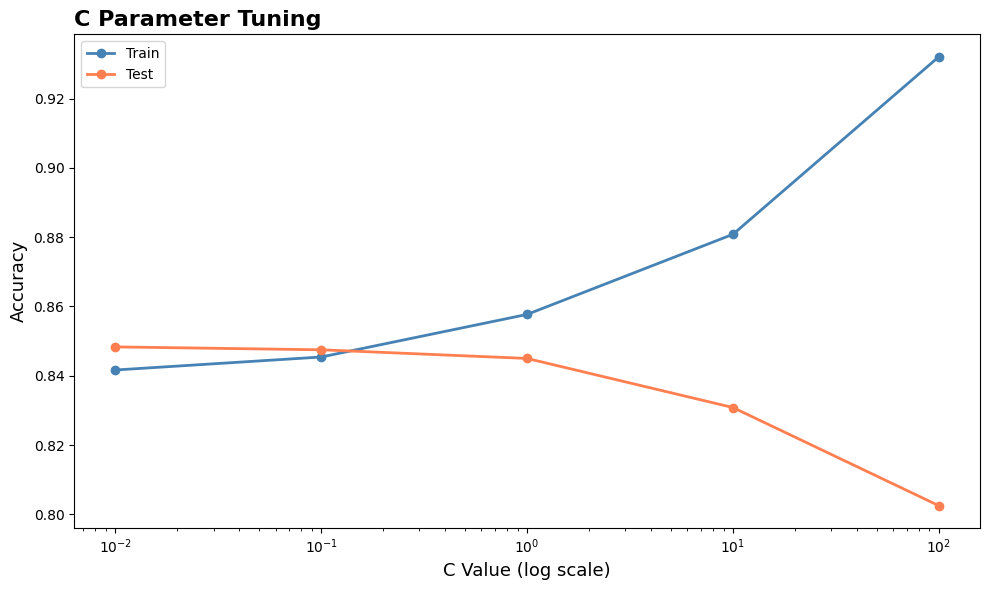

In [24]:
C_values = [0.01, 0.1, 1, 10, 100]
train_scores = []
test_scores  = []

for c in C_values:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=c, gamma='scale', random_state=42))
    ])
    pipe.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, pipe.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  pipe.predict(X_test)))

plt.figure(figsize=(10, 6))
plt.plot(C_values, train_scores, marker='o', label='Train',
         color='steelblue', linewidth=2)
plt.plot(C_values, test_scores,  marker='o', label='Test',
         color='coral', linewidth=2)
plt.xscale('log')
plt.xlabel('C Value (log scale)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('C Parameter Tuning', fontweight='bold',
          fontsize=16, loc='left')
plt.legend()
plt.tight_layout()
plt.show()

## **OverFitting**

In [25]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")
print(f"Gap:               {(train_acc - test_acc):.4f}")

Training Accuracy: 0.8577
Testing Accuracy:  0.8450
Gap:               0.0127


## **Chart**

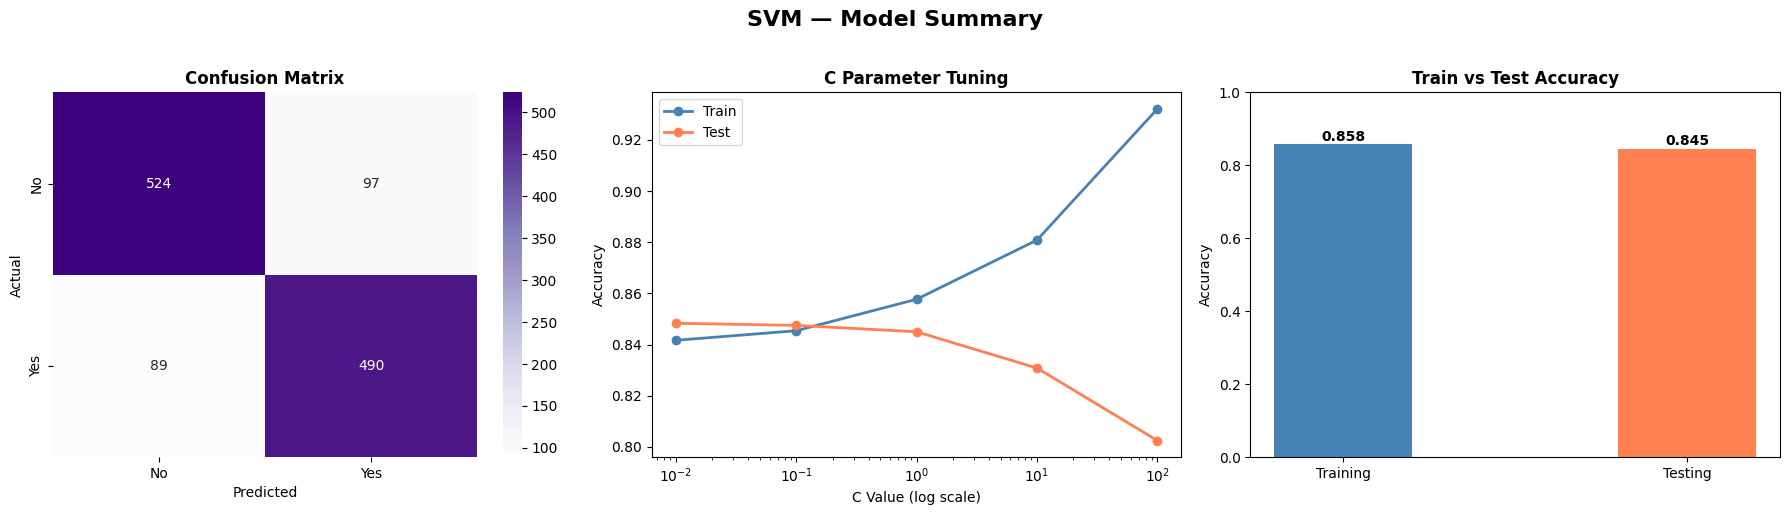

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2 — C Parameter Tuning
axes[1].plot(C_values, train_scores, marker='o',
             label='Train', color='steelblue', linewidth=2)
axes[1].plot(C_values, test_scores,  marker='o',
             label='Test',  color='coral',     linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('C Parameter Tuning', fontweight='bold')
axes[1].set_xlabel('C Value (log scale)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# Plot 3 — Train vs Test Accuracy
labels = ['Training', 'Testing']
scores = [train_acc, test_acc]
colors = ['steelblue', 'coral']
axes[2].bar(labels, scores, color=colors, width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Train vs Test Accuracy', fontweight='bold')
axes[2].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}',
                 ha='center', fontweight='bold')

plt.suptitle('SVM — Model Summary',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()